In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
data_dir = "../data/ice_melting/circle"

In [28]:
init_params = np.load(f"{data_dir}/initial_params.npy")
times = np.load(f"{data_dir}/times.npy")
init_params.shape

(1, 3)

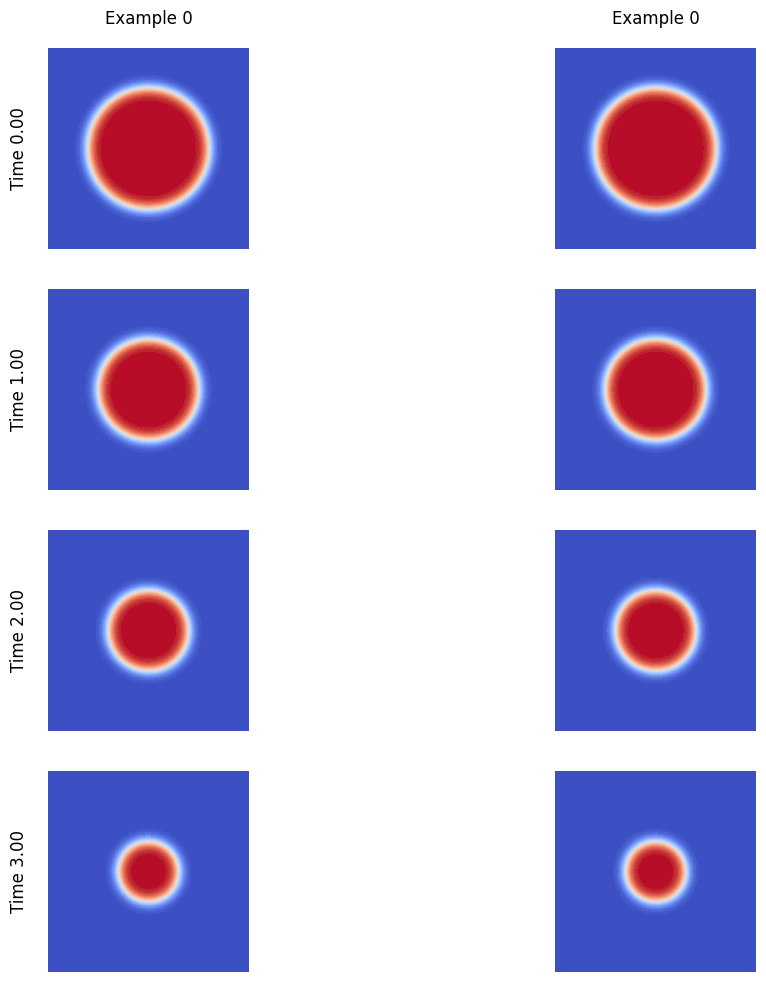

In [29]:
mesh = np.load(f"{data_dir}/mesh_points.npy") # shape: (2, H, W)
meshx = mesh[0]
meshy = mesh[1]
solutions = np.load(f"{data_dir}/solutions.npy") # shape: (num_examples, num_time_steps,C=1,  H, W)

tics = [0, 10, 20, 30]
examples = [0, 0]
fig, axs = plt.subplots(len(tics), len(examples), figsize=(12, 12))
for i, tic in enumerate(tics):
    for j, ex in enumerate(examples):
        sol = solutions[ex, tic, 0] # shape: (H, W)
        ax = axs[i, j]
        cont = ax.contourf(meshx, meshy, sol, levels=50, cmap='coolwarm')
        # ax.set_title(f'Example {ex}, Time {tic}')
        ax.set_aspect('equal')
        ax.set_axis_off()
        if i == 0:
            ax.text(0.5, 1.1, f'Example {ex}', transform=ax.transAxes, ha='center', va='bottom', fontsize=12)
        if j == 0:
            ax.text(-0.1, 0.5, f'Time {times[tic]:.2f}', transform=ax.transAxes, ha='right', va='center', rotation=90, fontsize=12)

In [30]:
solutions.shape # (num_examples, num_time_steps, C=1, H, W)
# # reshape as (num_examples, num_time_steps*h*W, 3) for evalution
num_examples, num_time_steps, C, H, W = solutions.shape
solutions_reshaped = solutions.transpose(0, 1, 3, 4, 2).reshape(num_examples, num_time_steps * H * W, C)
solutions_reshaped.shape

(1, 126976, 1)